In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import re
import string
import seaborn as sns

In [3]:
# Load the datasets
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

In [4]:
# Assign labels: 1 for fake news, 0 for true news
df_fake["class"] = 1
df_true["class"] = 0

C:\Users\Dzaki Pranaja\AppData\Local\Temp\ipykernel_21456\1744586487.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette=['blue', 'red'])


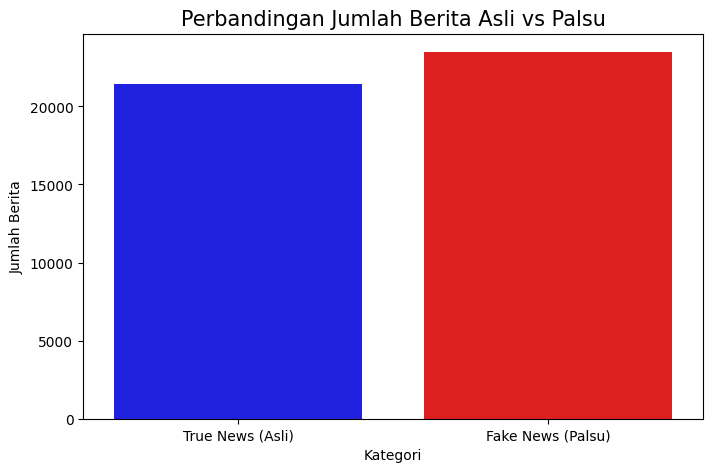

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df_merge atau df kamu sudah ada kolom 'class' (0=True, 1=Fake)
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df, palette=['blue', 'red'])

# Menambahkan label agar jelas
plt.title('Perbandingan Jumlah Berita Asli vs Palsu', fontsize=15)
plt.xticks([0, 1], ['True News (Asli)', 'Fake News (Palsu)'])
plt.ylabel('Jumlah Berita')
plt.xlabel('Kategori')

plt.show()

In [5]:
# Merge the datasets and drop unnecessary columns
df_merge = pd.concat([df_fake, df_true], axis=0)
df = df_merge.drop(['title', 'subject', 'date'], axis=1)

In [6]:
def wordopt(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\\W"," ",text) 
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df["text"] = df["text"].apply(wordopt)

In [7]:
x = df["text"]
y = df["class"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [8]:
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [9]:
model = LogisticRegression()
model.fit(xv_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
pred = model.predict(xv_test)
print("Akurasi:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Akurasi: 0.9877951002227171
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5303
           1       0.99      0.99      0.99      5922

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



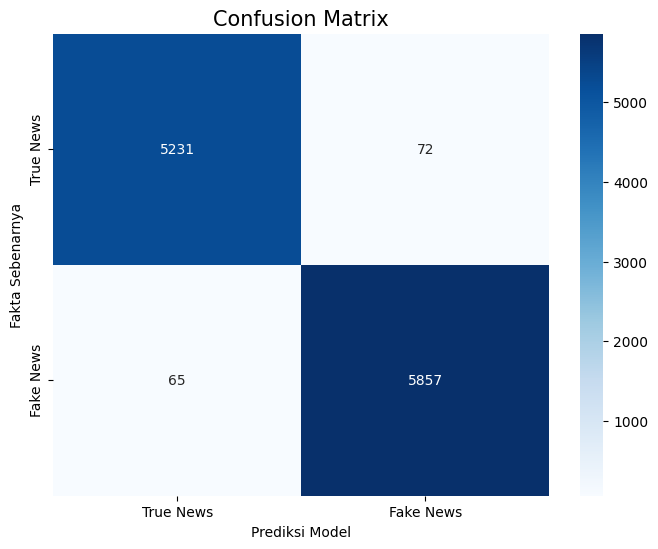

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Menghitung confusion matrix
# y_test = Kunci jawaban asli
# pred = Tebakan model
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['True News', 'Fake News'], 
            yticklabels=['True News', 'Fake News'])

plt.title('Confusion Matrix', fontsize=15)
plt.ylabel('Fakta Sebenarnya')
plt.xlabel('Prediksi Model')

plt.show()

In [12]:

# manual testing function
def manual_testing(news):
    # 1. Masukkan teks ke dalam dictionary agar mirip format dataframe
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    
    # 2. Bersihkan teks menggunakan fungsi wordopt yang sudah dibuat sebelumnya
    new_def_test["text"] = new_def_test["text"].apply(wordopt) 
    
    # 3. Ambil teksnya
    new_x_test = new_def_test["text"]
    
    # 4. Ubah teks jadi angka (Vectorization)
    # PENTING: Gunakan .transform(), JANGAN .fit_transform() 
    # karena kita mau pakai kamus kata yang sama dengan saat training tadi.
    # Pastikan variabel 'vectorization' atau 'vectorizer' sesuai dengan nama variabel kamu sebelumnya.
    new_xv_test = vectorization.transform(new_x_test)
    
    # 5. Lakukan Prediksi dengan Model
    pred_val = model.predict(new_xv_test)
    
    # 6. Kembalikan Hasil
    if pred_val[0] == 1:
        return "Fake News ⚠️"
    else:
        return "True News ✅"

In [13]:
# Tes 1: Berita Karangan Sendiri (Harusnya Fake)
input_text = "Breaking News: Aliens landed in New York today and met the President!"
prediction = manual_testing(input_text)
print(f"Berita: {input_text}")
print(f"Hasil: {prediction}")

Berita: Breaking News: Aliens landed in New York today and met the President!
Hasil: Fake News ⚠️
